# Praktikum - Logistic Regression
**Prediksi tingkat stress mahasiswa berdasarkan pola tugas dan jam tidur menggunakan logistic regression.**

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1. Membaca Dataset

In [6]:
# Membaca dataset
df = pd.read_csv('Survei Beban Tugas & Tingkat Stres Mahasiswa  (Jawaban)(Form Responses 1) (1).csv')
display(df.head())

,Timestamp,Nama Lengkap,NIM,jumlah tugas,jumlah deadline,rata rata jam tidur,Stress?,Stress
0,5/7/2026 10:37:10,Muhammad Rayhan Mumtaz,2024081040,5,5,7,Stress,1
1,5/7/2026 16:08:00,Elpam Jovi Anata,2025081046,2,1,10,Tidak Stress,0
2,5/7/2026 16:08:15,RAFDY THAFJANI RUSDIANSYAH,2025081013,1,0,4,Tidak Stress,0
3,5/7/2026 16:08:37,Aura Keyfas Brilea,2025011015,4,2,6,Tidak Stress,0
4,5/7/2026 16:08:46,Nabila Dwi Novianti,2025011017,5,1,5,Stress,1


## 2. Data Cleaning

In [7]:
# Menghapus data duplikat
df.drop_duplicates(inplace=True)

# Menghapus data kosong (missing values)
df.dropna(inplace=True)

# Memastikan format angka konsisten
df['jumlah tugas'] = pd.to_numeric(df['jumlah tugas'], errors='coerce')
df['jumlah deadline'] = pd.to_numeric(df['jumlah deadline'], errors='coerce')
df['rata rata jam tidur'] = pd.to_numeric(df['rata rata jam tidur'], errors='coerce')
df.dropna(inplace=True) # Drop jika ada nilai non-numerik yang berubah jadi NaN

# Mengubah label stress menjadi angka (0 = Tidak Stress, 1 = Stress)
# Menggunakan kolom 'Stress?' untuk mendapatkan nilai teksnya
df['Label'] = df['Stress?'].map({'Tidak Stress': 0, 'Stress': 1})
df.dropna(subset=['Label'], inplace=True) # Pastikan tidak ada missing label
df['Label'] = df['Label'].astype(int)

print("Info Dataset Setelah Cleaning:")
print(df.info())
display(df.head())

Info Dataset Setelah Cleaning:
<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Timestamp            37 non-null     str  
 1   Nama Lengkap         37 non-null     str  
 2   NIM                  37 non-null     int64
 3   jumlah tugas         37 non-null     int64
 4   jumlah deadline      37 non-null     int64
 5   rata rata jam tidur  37 non-null     int64
 6   Stress?              37 non-null     str  
 7   Stress               37 non-null     int64
 8   Label                37 non-null     int64
dtypes: int64(6), str(3)
memory usage: 2.7 KB
None


,Timestamp,Nama Lengkap,NIM,jumlah tugas,jumlah deadline,rata rata jam tidur,Stress?,Stress,Label
0,5/7/2026 10:37:10,Muhammad Rayhan Mumtaz,2024081040,5,5,7,Stress,1,1
1,5/7/2026 16:08:00,Elpam Jovi Anata,2025081046,2,1,10,Tidak Stress,0,0
2,5/7/2026 16:08:15,RAFDY THAFJANI RUSDIANSYAH,2025081013,1,0,4,Tidak Stress,0,0
3,5/7/2026 16:08:37,Aura Keyfas Brilea,2025011015,4,2,6,Tidak Stress,0,0
4,5/7/2026 16:08:46,Nabila Dwi Novianti,2025011017,5,1,5,Stress,1,1


## 3. Feature Selection

In [8]:
# Memilih fitur
X = df[['jumlah tugas', 'jumlah deadline', 'rata rata jam tidur']]

# Label / Target
y = df['Label']

print("Fitur (X):")
display(X.head())
print("\nTarget (y):")
display(y.head())

Fitur (X):


,jumlah tugas,jumlah deadline,rata rata jam tidur
0,5,5,7
1,2,1,10
2,1,0,4
3,4,2,6
4,5,1,5



Target (y):


0    1
1    0
2    0
3    0
4    1
Name: Label, dtype: int64

## 4. Split Data

In [9]:
# Membagi dataset menjadi data training dan data testing (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

Jumlah data training: 29
Jumlah data testing: 8


## 5. Training Model

In [10]:
# Menggunakan LogisticRegression untuk melatih model klasifikasi
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model berhasil dilatih!")

Model berhasil dilatih!


## 6. Prediction

In [11]:
# Melakukan prediksi terhadap data testing
y_pred = model.predict(X_test)

print("Hasil Prediksi: ", y_pred)
print("Label Asli:     ", y_test.values)

Hasil Prediksi:  [0 0 1 1 0 1 1 1]
Label Asli:      [1 1 1 1 0 1 1 1]


## 7. Evaluation

Accuracy: 0.75

Confusion Matrix:
[[1 0]
 [2 5]]


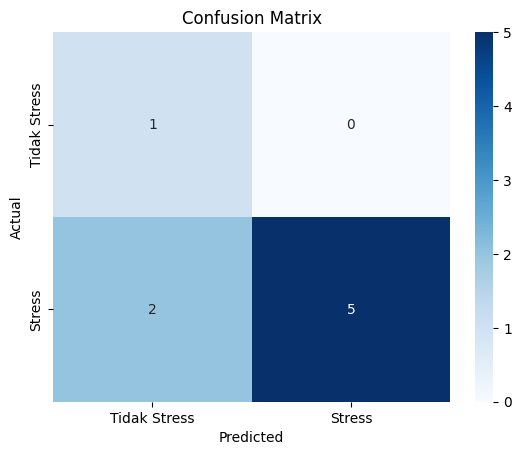


Classification Report:
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       1.00      0.71      0.83         7

    accuracy                           0.75         8
   macro avg       0.67      0.86      0.67         8
weighted avg       0.92      0.75      0.79         8



In [12]:
# Menampilkan accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}\n")

# Menampilkan confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tidak Stress', 'Stress'], 
            yticklabels=['Tidak Stress', 'Stress'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Menampilkan classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## 8. Probabilitas Prediksi

In [13]:
# Menampilkan probabilitas hasil prediksi
y_pred_proba = model.predict_proba(X_test)
print("Probabilitas Prediksi (data awal test set):")
print(y_pred_proba[:5])

if len(y_pred_proba) > 0:
    prob_tidak_stress = y_pred_proba[0][0] * 100
    prob_stress = y_pred_proba[0][1] * 100
    print("\nContoh Interpretasi untuk data pertama:")
    print(f"- {prob_tidak_stress:.2f}% kemungkinan tidak stress")
    print(f"- {prob_stress:.2f}% kemungkinan stress")

Probabilitas Prediksi (data awal test set):
[[0.76459071 0.23540929]
 [0.62713801 0.37286199]
 [0.37405038 0.62594962]
 [0.26410207 0.73589793]
 [0.89549672 0.10450328]]

Contoh Interpretasi untuk data pertama:
- 76.46% kemungkinan tidak stress
- 23.54% kemungkinan stress


## Analisis

**1. Mengapa logistic regression cocok untuk kasus ini?**  
Logistic regression sangat cocok digunakan untuk kasus ini karena tujuannya adalah memprediksi kategori/klasifikasi biner (dua kelas), yaitu apakah seorang mahasiswa "Stress" (1) atau "Tidak Stress" (0). Algoritma ini dirancang khusus untuk mencari probabilitas suatu observasi masuk ke salah satu dari dua kelas berdasarkan hubungan linear dari fitur independen.

**2. Mengapa probabilitas penting dalam prediksi stress?**  
Probabilitas sangat penting karena memberikan tingkat keyakinan (confidence score) terhadap prediksi yang dihasilkan. Mengetahui apakah seseorang diprediksi "Stress" dengan probabilitas 95% versus 52% sangat berbeda. Hal ini membantu dalam mengambil tindakan preventif yang lebih akurat (misal, siapa yang harus segera dibantu) alih-alih hanya mengandalkan label prediksi hitam-putih.

**3. Faktor apa yang paling memengaruhi stress mahasiswa?**  
Untuk melihat faktor paling berpengaruh, kita dapat melihat koefisien/bobot dari model logistic regression. Biasanya faktor seperti jumlah tugas dan jumlah deadline memiliki pengaruh positif (makin besar makin stress), sedangkan rata-rata jam tidur dapat memiliki pengaruh negatif (makin banyak tidur, risiko stress berkurang).

In [14]:
# Melihat bobot koefisien untuk mengetahui faktor dominan
koefisien = pd.DataFrame({'Fitur': X.columns, 'Koefisien': model.coef_[0]})
display(koefisien.sort_values(by='Koefisien', ascending=False))

,Fitur,Koefisien
0,jumlah tugas,0.460269
1,jumlah deadline,0.197788
2,rata rata jam tidur,-0.312088


**4. Apa kelemahan model yang dibuat?**  
- **Asumsi Linearitas**: Logistic regression berasumsi bahwa hubungan antara log-odds target dan fitur bersifat linear. Jika hubungan sebenarnya non-linear, prediksi bisa kurang optimal.
- **Dataset Sangat Kecil**: Mengingat jumlah observasi hanya beberapa puluh baris, model berisiko terkena *overfitting* atau *underfitting*, serta kurang merepresentasikan seluruh populasi mahasiswa.
- **Fitur Sederhana**: Model hanya menggunakan tiga fitur secara independen dan tidak memperhitungkan faktor eksternal lainnya yang mungkin jauh lebih kompleks (masalah pribadi, ekonomi, dll).